In [ ]:
# Setup do ambiente
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

np.random.seed(42)
tf.random.set_seed(42)

# Carregando e preparando o dataset MNIST
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalizar os pixels para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# "Achatar" as imagens 28x28 em vetores de 784 posicoes
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat = x_test.reshape((len(x_test), 784))

print("Shape treino:", x_train_flat.shape)
print("Shape teste:", x_test_flat.shape)

TensorFlow version: 2.20.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape treino: (60000, 784)
Shape teste: (10000, 784)


In [ ]:
# Construindo o Encoder

latent_dim = 32  # dimensao do espaco latente

encoder_input = keras.Input(shape=(784,), name="encoder_input")
x = layers.Dense(128, activation="relu")(encoder_input)
x = layers.Dense(64, activation="relu")(x)
latent = layers.Dense(latent_dim, activation="relu",
                       name="latent_space")(x)

encoder = keras.Model(encoder_input, latent, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,816 (432.88 KB)

 Trainable params: 110,816 (432.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Construindo o Decoder

decoder_input = keras.Input(shape=(latent_dim,), name="decoder_input")
x = layers.Dense(64, activation="relu")(decoder_input)
x = layers.Dense(128, activation="relu")(x)
decoder_output = layers.Dense(784, activation="sigmoid",
                               name="decoder_output")(x)

decoder = keras.Model(decoder_input, decoder_output, name="decoder")
decoder.summary()

# Montando o Autoencoder completo

autoencoder_input = keras.Input(shape=(784,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = keras.Model(autoencoder_input, decoded,
                           name="autoencoder")
autoencoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ decoder_input (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Dense)          │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,568 (435.81 KB)

 Trainable params: 111,568 (435.81 KB)

 Non-trainable params: 0 (0.00 B)

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       110,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       111,568 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,384 (868.69 KB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilando o modelo

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

# Treinando o Autoencoder

history = autoencoder.fit(
    x_train_flat, x_train_flat,   # entrada = alvo (reconstrucao)
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_flat, x_test_flat)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.2505 - val_loss: 0.1739
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1566 - val_loss: 0.1433
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1378 - val_loss: 0.1301
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.1268 - val_loss: 0.1211
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1190 - val_loss: 0.1150
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.1139 - val_loss: 0.1107
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1101 - val_loss: 0.1073
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1074 - val_loss: 0.1050
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1053 - val_loss: 0.1032
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1036 - val_loss: 0.1017
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.1022 - val_loss: 0.1003
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

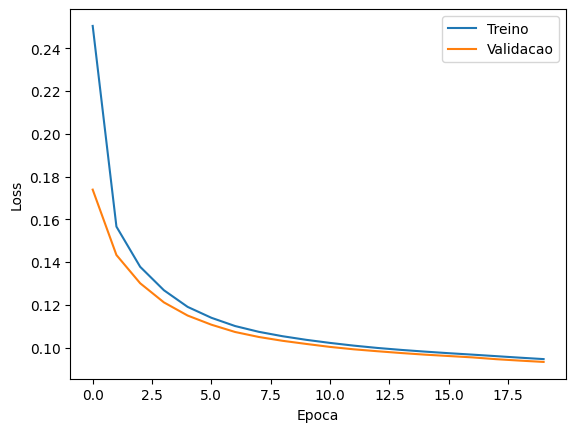

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


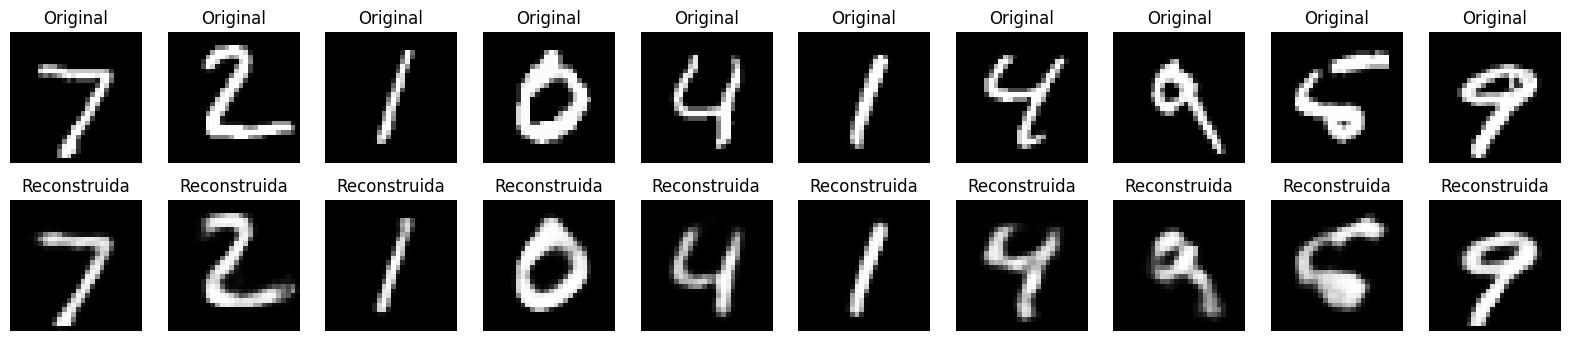

In [ ]:
# Curvas de treino
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validacao")
plt.xlabel("Epoca"); plt.ylabel("Loss")
plt.legend(); plt.show()

# Avaliando: original vs. reconstruido
decoded_imgs = autoencoder.predict(x_test_flat)

n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original"); plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.title("Reconstruida"); plt.axis("off")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


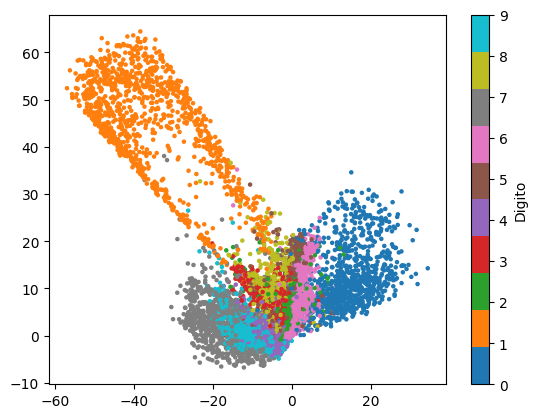

In [ ]:
# Explorando o espaco latente (visualizacao 2D)
latent_dim_2d = 2

enc_in = keras.Input(shape=(784,))
h = layers.Dense(32, activation="relu")(enc_in)
h = layers.Dense(16, activation="relu")(h)
z = layers.Dense(latent_dim_2d, activation="linear")(h)
encoder_2d = keras.Model(enc_in, z)

dec_in = keras.Input(shape=(latent_dim_2d,))
h2 = layers.Dense(16, activation="relu")(dec_in)
h2 = layers.Dense(32, activation="relu")(h2)
out2 = layers.Dense(784, activation="sigmoid")(h2)
decoder_2d = keras.Model(dec_in, out2)

ae_in = keras.Input(shape=(784,))
ae_2d = keras.Model(ae_in, decoder_2d(encoder_2d(ae_in)))
ae_2d.compile(optimizer="adam", loss="binary_crossentropy")
ae_2d.fit(x_train_flat, x_train_flat, epochs=20, batch_size=256,
          validation_data=(x_test_flat, x_test_flat), verbose=0)

z_test = encoder_2d.predict(x_test_flat)
plt.scatter(z_test[:, 0], z_test[:, 1], c=y_test,
            cmap="tab10", s=5)
plt.colorbar(label="Digito"); plt.show()